---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: Avaliação Comparativa dos Modelos de Sentimentos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/HuggingFace-FFD21E?style=for-the-badge&logo=huggingface&logoColor=black"/>
</div>

---

In [1]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
#%pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt

---

<div align="center">

## <span style="color:#1E90FF;">Carregamento dos Modelos</span>

</div>

Carregamos os três modelos salvos nos notebooks anteriores, cada um com seus respectivos artefatos de pré-processamento. A tabela abaixo resume os arquivos utilizados:

| Modelo | Artefatos carregados |
|--------|----------------------|
| **FCNN** | `fcnn_sentiment.keras` · `fcnn_tfidf.pkl` · `fcnn_label_encoder.pkl` |
| **BiLSTM** | `bilstm_sentiment.keras` · `bilstm_tokenizer.pkl` · `bilstm_label_encoder.pkl` |
| **DistilBERT** | `distilbert_sentiment/` · `distilbert_label_encoder.pkl` |

> **Nota sobre pré-processamento:** FCNN e BiLSTM foram treinados sobre texto processado com **spaCy** (lematização + remoção de stopwords). O DistilBERT recebe o **texto bruto** — seu tokenizador WordPiece trata a normalização internamente.

In [2]:
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import spacy
import torch

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')

# ── spaCy (pré-processamento para FCNN e BiLSTM) ─────────────────────────────

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')

def preprocess(text: str) -> str:
    """Lematiza e remove stopwords/pontuação — mesmo pipeline do treino."""
    doc = nlp(str(text))
    tokens = [
        tok.lemma_.lower().strip()
        for tok in doc
        if not tok.is_stop and not tok.is_punct and not tok.is_space
    ]
    return ' '.join([t for t in tokens if t])

# ── FCNN ─────────────────────────────────────────────────────────────────────

fcnn_model = load_model('models/fcnn_sentiment.keras')
fcnn_tfidf = pickle.load(open('models/fcnn_tfidf.pkl', 'rb'))
fcnn_le    = pickle.load(open('models/fcnn_label_encoder.pkl', 'rb'))

# ── BiLSTM ───────────────────────────────────────────────────────────────────

lstm_model = load_model('models/bilstm_sentiment.keras')
lstm_tok   = pickle.load(open('models/bilstm_tokenizer.pkl', 'rb'))
lstm_le    = pickle.load(open('models/bilstm_label_encoder.pkl', 'rb'))

LSTM_MAX_LEN = 100   # comprimento de padding usado no treino

# ── DistilBERT ───────────────────────────────────────────────────────────────

bert_tokenizer = AutoTokenizer.from_pretrained('models/distilbert_sentiment')
bert_model     = AutoModelForSequenceClassification.from_pretrained('models/distilbert_sentiment')
bert_le        = pickle.load(open('models/distilbert_label_encoder.pkl', 'rb'))

# move o modelo para o device disponível (MPS / CUDA / CPU)
DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
bert_model = bert_model.to(DEVICE)
bert_model.eval()

# rótulos e classes
CLASS_NAMES = list(fcnn_le.classes_)

print('Modelos carregados com sucesso!')
print(f'Classes: {CLASS_NAMES}')
print(f'Device (DistilBERT): {DEVICE}')

/Users/mitoura/Desktop/FIAP/Materiais/GenerativeAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelos carregados com sucesso!
Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Device (DistilBERT): mps


---

<div align="center">

## <span style="color:#1E90FF;">Exemplos para Avaliação</span>

</div>

Os exemplos são amostrados diretamente do **conjunto de teste** (`data_test.txt`) — dados que os modelos **nunca viram durante o treinamento**. Para garantir uma avaliação balanceada, selecionamos **3 exemplos por classe** (18 no total), escolhidos aleatoriamente com semente fixa para reprodutibilidade.

In [6]:
import random

SEED_SAMPLE   = 42
N_POR_CLASSE  = 3   # exemplos amostrados por classe

def load_dataset(path: str) -> pd.DataFrame:
    """
    Lê o dataset separado por ';' dividindo sempre pelo ÚLTIMO ponto e vírgula,
    garantindo que textos que contenham ';' sejam lidos corretamente.
    Formato esperado por linha:  texto;sentimento
    """
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            idx = line.rfind(';')          # separa pelo último ';'
            records.append({
                'texto'     : line[:idx],
                'sentimento': line[idx + 1:],
            })
    return pd.DataFrame(records)

# carrega o conjunto de teste
df_test = load_dataset('dataset/data_test.txt')

# amostragem estratificada: N_POR_CLASSE por sentimento, seed fixa
# pd.concat por classe evita o KeyError do groupby().apply() no pandas 2.x
exemplos_df = pd.concat([
    df_test[df_test['sentimento'] == cls].sample(N_POR_CLASSE, random_state=SEED_SAMPLE)
    for cls in sorted(df_test['sentimento'].unique())
]).reset_index(drop=True)

frases        = exemplos_df['texto'].tolist()
rotulos_reais = exemplos_df['sentimento'].tolist()

# exibe a tabela de exemplos selecionados
print(f'{len(frases)} exemplos amostrados do conjunto de teste ({N_POR_CLASSE} por classe)\n')
for i, (txt, lbl) in enumerate(zip(frases, rotulos_reais)):
    print(f'{i+1:2d}. [{lbl:8s}] {txt[:95]}{"..." if len(txt) > 95 else ""}')

18 exemplos amostrados do conjunto de teste (3 por classe)

 1. [anger   ] i wake too early so i feel grumpy
 2. [anger   ] i was feeling like i said humour gets me through im one of those people who even if i spoke abo...
 3. [anger   ] i should pull out if i feel resentful or edgy
 4. [fear    ] im feeling pretty anxious
 5. [fear    ] i woke up today feeling kind of strange
 6. [fear    ] i am and i am looking for some vest tops i have some shorts but long ones due to feel paranoid ...
 7. [joy     ] i have spent of my waking hours enjoying the freedom of not owning a cellphone feeling smug abo...
 8. [joy     ] i like being in church on sundays it makes me feel more virtuous how self effacing and more set...
 9. [joy     ] im begging fate not to mess with the next cycle to let it look as pretty as this one so i can a...
10. [love    ] i was feeling the need for some christmas crafting this week especially after seeing a couple o...
11. [love    ] i can feel the warmth of the gentle

---

<div align="center">

## <span style="color:#1E90FF;">Predições dos Modelos</span>

</div>

Aplicamos cada modelo ao conjunto de exemplos, respeitando o pipeline de inferência de cada arquitetura. Os resultados são apresentados lado a lado para facilitar a comparação.

In [7]:
# ── Pré-processamento com spaCy (FCNN e BiLSTM) ──────────────────────────────

frases_proc = [preprocess(f) for f in frases]

# ── FCNN ─────────────────────────────────────────────────────────────────────

X_fcnn      = fcnn_tfidf.transform(frases_proc).astype('float32').toarray()
fcnn_probs  = fcnn_model.predict(X_fcnn, verbose=0)
fcnn_preds  = fcnn_le.inverse_transform(fcnn_probs.argmax(axis=-1))

# ── BiLSTM ───────────────────────────────────────────────────────────────────

seqs        = lstm_tok.texts_to_sequences(frases_proc)
X_lstm      = pad_sequences(seqs, maxlen=LSTM_MAX_LEN, padding='post', truncating='post')
lstm_probs  = lstm_model.predict(X_lstm, verbose=0)
lstm_preds  = lstm_le.inverse_transform(lstm_probs.argmax(axis=-1))

# ── DistilBERT ───────────────────────────────────────────────────────────────

bert_inputs = bert_tokenizer(frases, truncation=True, max_length=128,
                             padding=True, return_tensors='pt')
bert_inputs = {k: v.to(DEVICE) for k, v in bert_inputs.items()}

with torch.no_grad():
    bert_out   = bert_model(**bert_inputs)
    bert_probs = torch.softmax(bert_out.logits, dim=-1).cpu().numpy()

bert_preds = bert_le.inverse_transform(bert_probs.argmax(axis=-1))

# ── Exibição dos resultados ───────────────────────────────────────────────────

MARK = {True: '✓', False: '✗'}

print(f'{"#":<3} {"Real":<12} {"FCNN":<14} {"BiLSTM":<14} {"DistilBERT":<14}  Frase')
print('─' * 100)
for i, (real, fp, lp, bp, frase) in enumerate(
        zip(rotulos_reais, fcnn_preds, lstm_preds, bert_preds, frases)):
    fc = f'{fp} {MARK[fp == real]}'
    lc = f'{lp} {MARK[lp == real]}'
    bc = f'{bp} {MARK[bp == real]}'
    trecho = frase[:55] + '...' if len(frase) > 55 else frase
    print(f'{i+1:<3} {real:<12} {fc:<14} {lc:<14} {bc:<14}  {trecho}')

print('─' * 100)
rotulos_arr = np.array(rotulos_reais)
print(f'{"Acurácia":<15}'
      f'{(fcnn_preds == rotulos_arr).mean():<14.1%}'
      f'{(lstm_preds == rotulos_arr).mean():<14.1%}'
      f'{(bert_preds == rotulos_arr).mean():.1%}')

#   Real         FCNN           BiLSTM         DistilBERT      Frase
────────────────────────────────────────────────────────────────────────────────────────────────────
1   anger        anger ✓        anger ✓        anger ✓         i wake too early so i feel grumpy
2   anger        love ✗         sadness ✗      anger ✓         i was feeling like i said humour gets me through im one...
3   anger        anger ✓        anger ✓        anger ✓         i should pull out if i feel resentful or edgy
4   fear         fear ✓         fear ✓         fear ✓          im feeling pretty anxious
5   fear         fear ✓         fear ✓         fear ✓          i woke up today feeling kind of strange
6   fear         fear ✓         fear ✓         fear ✓          i am and i am looking for some vest tops i have some sh...
7   joy          joy ✓          joy ✓          joy ✓           i have spent of my waking hours enjoying the freedom of...
8   joy          joy ✓          joy ✓          joy ✓           i l

---

<div align="center">

## <span style="color:#1E90FF;">Comparação dos Resultados</span>

</div>

A comparação é apresentada em três visualizações complementares:

1. **Mapa de acertos** — grade modelos × exemplos com verde (correto) e vermelho (errado);
2. **Confiança na classe correta** — para cada exemplo, o quanto cada modelo apostou na resposta certa;
3. **Acurácia por classe** — percentual de acertos de cada modelo por sentimento.

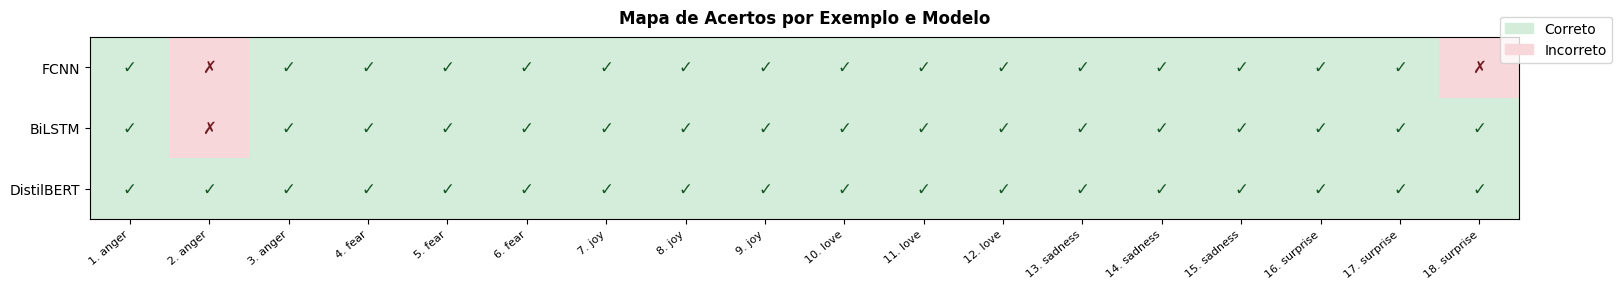

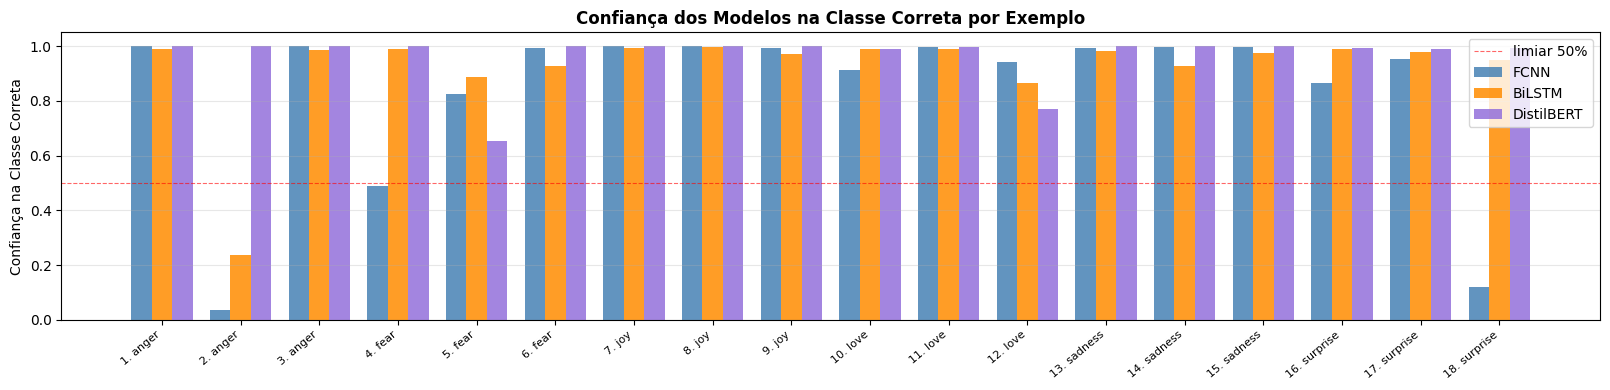

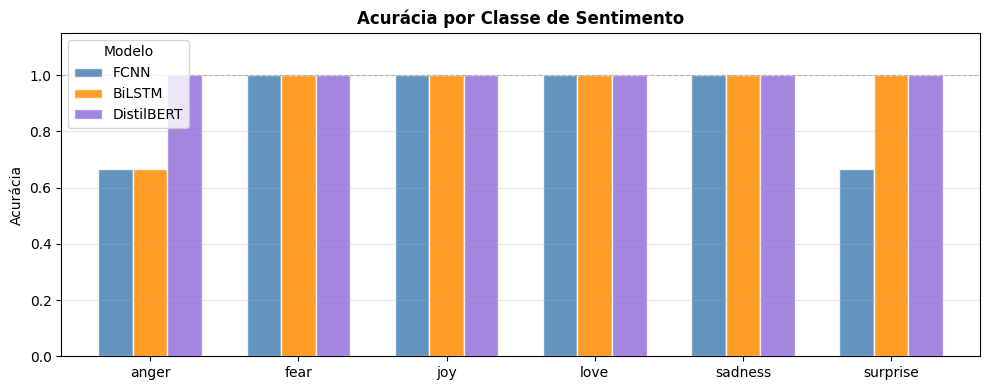

In [8]:
n_exemplos  = len(frases)
rotulos_arr = np.array(rotulos_reais)

# matriz de acertos (3 modelos × n_exemplos)
acertos = np.array([
    fcnn_preds == rotulos_arr,
    lstm_preds == rotulos_arr,
    bert_preds == rotulos_arr,
]).astype(int)  # 1 = correto, 0 = errado

labels_eixo = [f'{i+1}. {r}' for i, r in enumerate(rotulos_reais)]
modelos     = ['FCNN', 'BiLSTM', 'DistilBERT']

# ── Figura 1: mapa de acertos ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(max(14, n_exemplos * 0.9), 3))
cmap = plt.matplotlib.colors.ListedColormap(['#f8d7da', '#d4edda'])
ax.imshow(acertos, aspect='auto', cmap=cmap, vmin=0, vmax=1)

for m in range(3):
    for e in range(n_exemplos):
        simbolo = '✓' if acertos[m, e] else '✗'
        cor     = '#155724' if acertos[m, e] else '#721c24'
        ax.text(e, m, simbolo, ha='center', va='center', fontsize=12, color=cor, fontweight='bold')

ax.set_xticks(range(n_exemplos))
ax.set_xticklabels(labels_eixo, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(3))
ax.set_yticklabels(modelos, fontsize=10)
ax.set_title('Mapa de Acertos por Exemplo e Modelo', fontsize=12, fontweight='bold', pad=10)

verde    = mpatches.Patch(color='#d4edda', label='Correto')
vermelho = mpatches.Patch(color='#f8d7da', label='Incorreto')
ax.legend(handles=[verde, vermelho], loc='upper right', bbox_to_anchor=(1.07, 1.15))
plt.tight_layout()
plt.show()

# ── Figura 2: confiança na classe correta ─────────────────────────────────────

def conf_correta(probs, le, rotulos):
    """Extrai a probabilidade atribuída pelo modelo à classe correta de cada exemplo."""
    return np.array([
        probs[i, list(le.classes_).index(r)]
        for i, r in enumerate(rotulos)
    ])

fcnn_conf = conf_correta(fcnn_probs, fcnn_le, rotulos_reais)
lstm_conf = conf_correta(lstm_probs, lstm_le, rotulos_reais)
bert_conf = conf_correta(bert_probs, bert_le, rotulos_reais)

x     = np.arange(n_exemplos)
width = 0.26
fig, ax = plt.subplots(figsize=(max(14, n_exemplos * 0.9), 4))

ax.bar(x - width, fcnn_conf, width, label='FCNN',       color='steelblue',    alpha=0.85)
ax.bar(x,          lstm_conf, width, label='BiLSTM',     color='darkorange',   alpha=0.85)
ax.bar(x + width,  bert_conf, width, label='DistilBERT', color='mediumpurple', alpha=0.85)

ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='limiar 50%')
ax.set_xticks(x)
ax.set_xticklabels(labels_eixo, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Confiança na Classe Correta')
ax.set_ylim(0, 1.05)
ax.set_title('Confiança dos Modelos na Classe Correta por Exemplo', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figura 3: acurácia por classe ─────────────────────────────────────────────

acc_por_classe = {}
for cls in CLASS_NAMES:
    idx = [i for i, r in enumerate(rotulos_reais) if r == cls]
    acc_por_classe[cls] = {
        'FCNN'      : np.mean([fcnn_preds[i] == cls for i in idx]),
        'BiLSTM'    : np.mean([lstm_preds[i] == cls for i in idx]),
        'DistilBERT': np.mean([bert_preds[i] == cls for i in idx]),
    }

df_acc = pd.DataFrame(acc_por_classe).T
fig, ax = plt.subplots(figsize=(10, 4))
df_acc.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange', 'mediumpurple'],
            alpha=0.85, edgecolor='white', width=0.7)
ax.set_xticklabels(CLASS_NAMES, rotation=0, fontsize=10)
ax.set_ylabel('Acurácia')
ax.set_ylim(0, 1.15)
ax.set_title('Acurácia por Classe de Sentimento', fontsize=12, fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(title='Modelo')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

<div align="center">

## <span style="color:#1E90FF;">Resumo Comparativo</span>

</div>

,Acurácia,Acertos,Confiança Média
Modelo,,,
FCNN,88.9%,16 / 18,83.9%
BiLSTM,94.4%,17 / 18,92.3%
DistilBERT,100.0%,18 / 18,96.5%


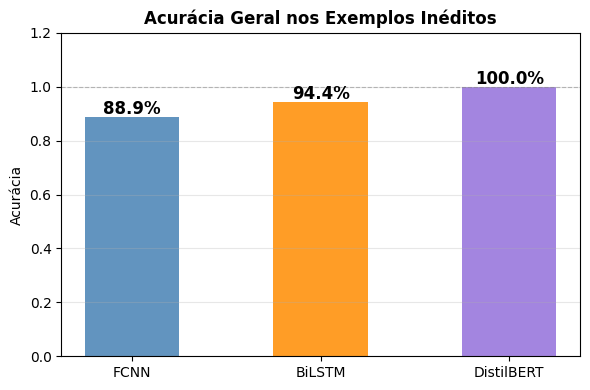

In [9]:
MODELOS   = ['FCNN', 'BiLSTM', 'DistilBERT']
ALL_PREDS = [fcnn_preds, lstm_preds, bert_preds]
ALL_PROBS = [fcnn_probs, lstm_probs, bert_probs]
ALL_LE    = [fcnn_le,    lstm_le,    bert_le]

rows = []
for modelo, preds, probs, le in zip(MODELOS, ALL_PREDS, ALL_PROBS, ALL_LE):
    acuracia    = (preds == rotulos_arr).mean()
    conf_media  = conf_correta(probs, le, rotulos_reais).mean()
    acertos_n   = (preds == rotulos_arr).sum()
    rows.append({
        'Modelo'             : modelo,
        'Acurácia'           : f'{acuracia:.1%}',
        'Acertos'            : f'{acertos_n} / {len(frases)}',
        'Confiança Média'    : f'{conf_media:.1%}',
    })

df_resumo = pd.DataFrame(rows).set_index('Modelo')

# estilização: destaca melhor valor de cada coluna em verde
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

display(
    df_resumo.style
    .apply(highlight_max, subset=['Acurácia', 'Confiança Média'])
    .set_caption('Resumo Comparativo — Exemplos Inéditos')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
)

# gráfico radar / acurácia geral
fig, ax = plt.subplots(figsize=(6, 4))
accs = [(preds == rotulos_arr).mean() for preds in ALL_PREDS]
bars = ax.bar(MODELOS, accs, color=['steelblue', 'darkorange', 'mediumpurple'], alpha=0.85, width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia Geral nos Exemplos Inéditos', fontsize=12, fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()